# Thermal Radiation
All objects with a temperature above absolute zero emit electromagnetic radiation. Electromagnetic radiation covers the whole spectrum: from gamma rays all the way to radio waves. The definition of each type of radiation is based on wavelength, and can be seen in [](#fig:wavelengths) 

:::{figure} ../figures/radiationspectrum.png
:label: fig:wavelengths
:width: 80%
Electromagnetic radiation spectrum
:::

## Planck's Law

The spectral emissive power of a blackbody is

$$
E_\lambda
=
\frac{2\pi hc^2}
{\lambda^5
\left(
e^{hc/\lambda kT}
-1
\right)}
$$

where

- $h$ = Planck constant
- $c$ = speed of light
- $k$ = Boltzmann constant
- $T$ = temperature

---

## Wien's Displacement Law

The wavelength corresponding to the maximum emissive power is

$$
\lambda_{max}
T
=
2.898\times10^{-3}
\;mK
$$

As temperature increases, the peak shifts towards shorter wavelengths.

---

## Stefan-Boltzmann Law

The total emissive power equals

$$
E=\sigma T^4
$$

where

$$
\sigma
=
5.670\times10^{-8}
\;W/m^2K^4
$$

The area under the Planck curve therefore grows very rapidly with temperature.


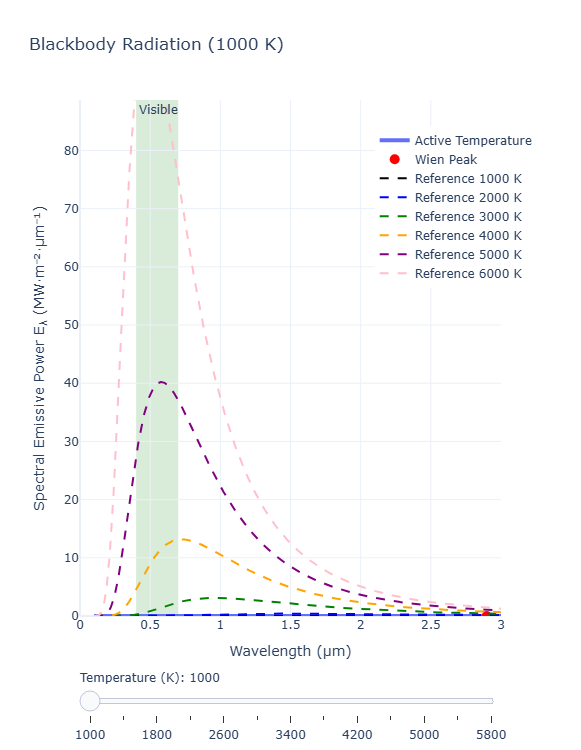

In [8]:
import numpy as np
import plotly.graph_objects as go

#===================================
#Physics class about BlackBodies
#===================================

class BlackBody:

    h = 6.62607015e-34 #plancks constant
    c = 2.99792458e8 #speed of light
    k = 1.380649e-23 #Boltzmann constant
    sigma = 5.670374419e-8

    def __init__(self, temperature):
        self.temperature = temperature

    def planck(self, wavelength):

        T = self.temperature

        exponent = (
            self.h * self.c /
            (wavelength * self.k * T)
        )

        numerator = (
            2 * np.pi * self.h * self.c**2
        )

        denominator = (
            wavelength**5 *
            (np.exp(exponent) - 1)
        )

        return numerator / denominator * 1e-12

    def wien_peak(self):

        b = 2.897771955e-3

        return b / self.temperature

    def stefan_boltzmann(self):

        return self.sigma * self.temperature**4

# =============================================================================
# Settings (temp and wavelength ranges)
# =============================================================================


temperatures = np.arange(
    1000,
    6001,
    400
)

wavelength_um = np.linspace(
    0.1,
    3,
    1000
)

wavelength_m = wavelength_um * 1e-6


# =============================================================================
# Create Figure
# =============================================================================

fig = go.Figure()

# =============================================================================
# Precompute all Active Temperature Curves
# =============================================================================

curve_data = {}
peak_data = {}

max_E = 0

for T in temperatures:

    bb = BlackBody(T)

    E = bb.planck(wavelength_m)
    max_E = max(max_E, np.max(E))

    peak_wavelength = bb.wien_peak() * 1e6

    peak_index = np.argmin(
        np.abs(wavelength_um - peak_wavelength)
    )

    curve_data[T] = E

    peak_data[T] = (
        peak_wavelength,
        E[peak_index]
    )

# =============================================================================
# Active Curve (Initially 1000 K)
# =============================================================================

initial_temperature = temperatures[0]

fig.add_trace(
    go.Scatter(
        x=wavelength_um,
        y=curve_data[initial_temperature],
        mode="lines",
        line=dict(width=4),
        name="Active Temperature",
        hovertemplate=
        "λ=%{x:.2f} μm<br>"
        "E=%{y:.3e}<extra></extra>"
    )
)

# =============================================================================
# Wien Peak Marker
# =============================================================================

fig.add_trace(
    go.Scatter(
        x=[peak_data[initial_temperature][0]],
        y=[peak_data[initial_temperature][1]],
        mode="markers",
        marker=dict(
            color="red",
            size=10
        ),
        name="Wien Peak",
        hovertemplate=
        "Wien Peak<br>"
        "λ=%{x:.2f} μm<extra></extra>"
    )
)

# =============================================================================
# Reference Curves
# =============================================================================

reference_temperatures = [
    1000,
    2000,
    3000,
    4000,
    5000,
    6000
]

colors = [
    "black",
    "blue",
    "green",
    "orange",
    "purple",
    "pink"
]

for T_ref, color in zip(reference_temperatures, colors):

    bb_ref = BlackBody(T_ref)

    E_ref = bb_ref.planck(wavelength_m)

    fig.add_trace(
        go.Scatter(
            x=wavelength_um,
            y=E_ref,
            mode="lines",
            line=dict(
                dash="dash",
                width=2,
                color=color
            ),
            name=f"Reference {T_ref} K",
            visible=True,
            hovertemplate=
            f"T={T_ref} K<br>"
            "λ=%{x:.2f} μm<br>"
            "E=%{y:.3e}<extra></extra>"
        )
    )

# =============================================================================
# Visible Spectrum Band
# =============================================================================

fig.add_vrect(
    x0=0.4,
    x1=0.7,
    fillcolor="green",
    opacity=0.15,
    layer="below",
    line_width=0,
    annotation_text="Visible",
    annotation_position="top left"
)

# =============================================================================
# Slider Definition
# =============================================================================

steps = []

for T in temperatures:

    peak_x = peak_data[T][0]
    peak_y = peak_data[T][1]

    step = dict(
        method="restyle",

        args=[
            {
                "x": [
                    wavelength_um,
                    [peak_x]
                ],
                "y": [
                    curve_data[T],
                    [peak_y]
                ]
            },
            [0, 1]   # ONLY update traces 0 and 1
        ],

        label=str(T)
    )
    steps.append(step)

# =============================================================================
# Layout
# =============================================================================

fig.update_layout(

    title=f"Blackbody Radiation ({initial_temperature} K)",

    sliders=[
        dict(
            active=0,

            currentvalue={
                "prefix":
                "Temperature (K): "
            },

            pad={"t": 50},

            steps=steps
        )
    ],

    xaxis=dict(
        range=[0, 3]
    ),

    xaxis_title="Wavelength (μm)",

    yaxis=dict(
        range=[0, 1.05*max_E]
    ),

    yaxis_title=
    "Spectral Emissive Power E<sub>λ</sub> (MW·m⁻²·μm⁻¹)",
    
    template="plotly_white",

    autosize=True,

    height=750,

    legend=dict(
        x=0.70,
        y=0.95
    )
)

# =============================================================================
# Display Figure
# =============================================================================

fig

In [11]:
from jupyterquiz import display_quiz

display_quiz("../quiz/wien_quiz.json")

<IPython.core.display.Javascript object>